In [1]:
import sys  
import os  
import torch
from finetuning_scripts.finetune_tabpfn_main import fine_tune_tabpfn
from sklearn.datasets import load_iris
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier
import pandas as pd
import numpy as np

from sklearn.metrics import (  
    accuracy_score,  
    precision_score,  
    recall_score,  
    f1_score,  
    roc_curve,  
    auc,  
    precision_recall_curve,  
    log_loss,  
    classification_report  
)  
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 
import matplotlib.pyplot as plt 

In [2]:
train = pd.read_csv('支持集——30个特征+抗衰概率.csv')  
# 分离特征和标签  
X = train.iloc[:, 3:] 
y = train['senolytic']  

# 第一次分割：将数据分为训练集和临时集（80% 训练集，20% 临时集）  
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)  

# 第二次分割：将临时集分为验证集和测试集（10% 验证集，10% 测试集）  
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) 

Fine-tuning Steps:   0%|          | 49/10000 [00:41<2:23:47,  1.15it/s, Best Val. Loss=0.369, Best Val. Score=-.369, Training Loss=0.353, Val. Loss=0.38, Patience=0, Time=16.9, Utilization=100, Grad Norm=1.62]  


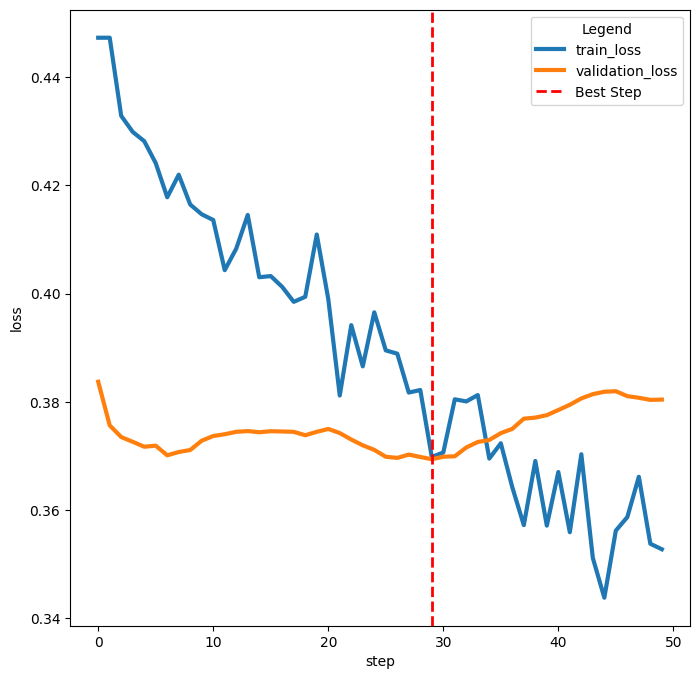

In [3]:
save_path_to_fine_tuned_model = "./fine_tuned_model.ckpt"
model_path = 'tabpfn-v2-classifier.ckpt' 

# 创建 TabPFNClassifier 实例，指定模型路径  
clf = TabPFNClassifier(device='cuda', model_path=model_path)  # 使用 model_path 参数 

fine_tune_tabpfn(
    path_to_base_model='tabpfn-v2-classifier.ckpt' ,
    save_path_to_fine_tuned_model=save_path_to_fine_tuned_model,
    # Finetuning HPs
    time_limit=60,
    finetuning_config={"learning_rate": 0.00001, "batch_size": 20},
    validation_metric="log_loss",
    # Input Data
    X_train=X_train,
    y_train=y_train,
    categorical_features_index=None,
    device="cuda",  # use "cpu" if you don't have a GPU
    task_type="multiclass",
    # Optional
    show_training_curve=True,  # Shows a final report after finetuning.
    logger_level=0,  # Shows all logs, higher values shows less
    use_wandb=False,  # Init wandb yourself, and set to True
)

In [4]:
# Evaluate on Test Data
clf1 = TabPFNClassifier(model_path=save_path_to_fine_tuned_model).fit(X_train, y_train) 
print("Log Loss (Finetuned):", log_loss(y_test, clf1.predict_proba(X_test)))

Log Loss (Finetuned): 0.2761516147877616


Log Loss (Finetuned): 0.2761516147877616

Confusion Matrix:
 [[77  4]
 [ 4 15]]
Accuracy: 0.92
Precision: 0.7894736842105263
Recall: 0.7894736842105263
F1 Score: 0.7894736842105263

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        81
           1       0.79      0.79      0.79        19

    accuracy                           0.92       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.92      0.92      0.92       100



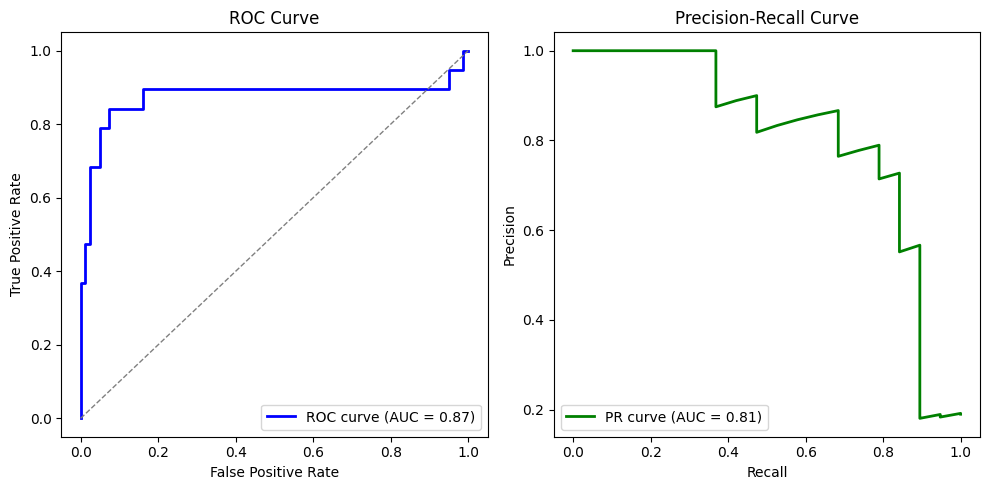

In [5]:
y_pred = clf1.predict(X_test)  
y_pred_proba = clf1.predict_proba(X_test)  

# 打印Log Loss  
print("Log Loss (Finetuned):", log_loss(y_test, y_pred_proba))  

# 计算其他评价指标  
accuracy = accuracy_score(y_test, y_pred)  
precision = precision_score(y_test, y_pred, average='binary')  # 如果是多分类，改为 `average='weighted'`  
recall = recall_score(y_test, y_pred, average='binary')  
f1 = f1_score(y_test, y_pred, average='binary')  
cm = confusion_matrix(y_test, y_pred)  

# 打印混淆矩阵  
print("\nConfusion Matrix:\n", cm)  

print("Accuracy:", accuracy)  
print("Precision:", precision)  
print("Recall:", recall)  
print("F1 Score:", f1)  

# 打印分类报告  
print("\nClassification Report:\n", classification_report(y_test, y_pred))  

# 绘制ROC曲线  
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])  # 假设是二分类，取第二列概率  
roc_auc = auc(fpr, tpr)  

plt.figure(figsize=(10, 5))  
plt.subplot(1, 2, 1)  
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')  
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  
plt.xlabel('False Positive Rate')  
plt.ylabel('True Positive Rate')  
plt.title('ROC Curve')  
plt.legend(loc="lower right")  

# 绘制PR曲线  
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])  
pr_auc = auc(recall_vals, precision_vals)  

plt.subplot(1, 2, 2)  
plt.plot(recall_vals, precision_vals, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')  
plt.xlabel('Recall')  
plt.ylabel('Precision')  
plt.title('Precision-Recall Curve')  
plt.legend(loc="lower left")  

plt.tight_layout()  
plt.show()  

In [6]:
# Compare to the default model
#clf = TabPFNClassifier().fit(X_train, y_train)
clf2 = TabPFNClassifier(device='cuda', model_path=model_path).fit(X_train, y_train)
print("Log Loss (Default):", log_loss(y_test, clf2.predict_proba(X_test)))

Log Loss (Default): 0.2748413598259472


Log Loss (Finetuned): 0.2748413598259472

Confusion Matrix:
 [[77  4]
 [ 7 12]]
Accuracy: 0.89
Precision: 0.75
Recall: 0.631578947368421
F1 Score: 0.6857142857142857

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93        81
           1       0.75      0.63      0.69        19

    accuracy                           0.89       100
   macro avg       0.83      0.79      0.81       100
weighted avg       0.89      0.89      0.89       100



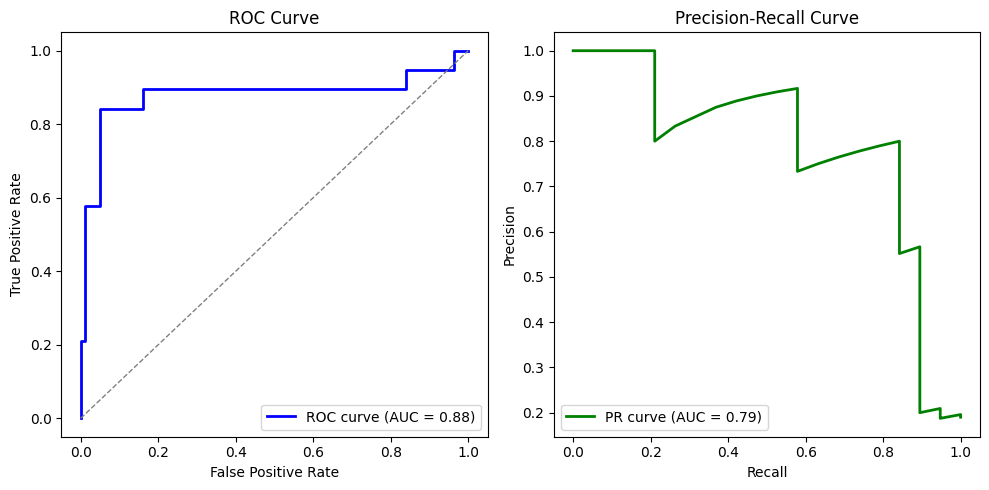

In [7]:
y_pred = clf2.predict(X_test)  
y_pred_proba = clf2.predict_proba(X_test)  

# 打印Log Loss  
print("Log Loss (Finetuned):", log_loss(y_test, y_pred_proba))  

# 计算其他评价指标  
accuracy = accuracy_score(y_test, y_pred)  
precision = precision_score(y_test, y_pred, average='binary')  # 如果是多分类，改为 `average='weighted'`  
recall = recall_score(y_test, y_pred, average='binary')  
f1 = f1_score(y_test, y_pred, average='binary')  
cm = confusion_matrix(y_test, y_pred)  

# 打印混淆矩阵  
print("\nConfusion Matrix:\n", cm)  

print("Accuracy:", accuracy)  
print("Precision:", precision)  
print("Recall:", recall)  
print("F1 Score:", f1)  

# 打印分类报告  
print("\nClassification Report:\n", classification_report(y_test, y_pred))  

# 绘制ROC曲线  
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])  # 假设是二分类，取第二列概率  
roc_auc = auc(fpr, tpr)  

plt.figure(figsize=(10, 5))  
plt.subplot(1, 2, 1)  
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')  
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  
plt.xlabel('False Positive Rate')  
plt.ylabel('True Positive Rate')  
plt.title('ROC Curve')  
plt.legend(loc="lower right")  

# 绘制PR曲线  
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])  
pr_auc = auc(recall_vals, precision_vals)  

plt.subplot(1, 2, 2)  
plt.plot(recall_vals, precision_vals, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')  
plt.xlabel('Recall')  
plt.ylabel('Precision')  
plt.title('Precision-Recall Curve')  
plt.legend(loc="lower left")  

plt.tight_layout()  
plt.show()  